In [16]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pathlib import Path
import os
load_dotenv()

True

In [3]:
docs = []
for pdf_file in Path("./documents").glob("*.pdf"):
    docs.extend(PyPDFLoader(str(pdf_file)).load())

In [4]:
len(docs)

2123

In [5]:
# create smaller chunks from documents
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# to avoid unicode errors
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [6]:
len(chunks)

6396

In [ ]:
# embed docs and create vector store
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

if os.path.exists("faiss_index"):
    vector_store = FAISS.load_local(
        "faiss_index",
        embeddings,
        allow_dangerous_deserialization=True
    )
    print("Loaded existing FAISS index.")
else:
    print("here")
    vector_store = FAISS.from_documents(chunks, embeddings)
    vector_store.save_local("faiss_index")
    print("Created and saved new FAISS index.")

Loaded existing FAISS index.


In [18]:
if not os.path.exists("faiss_index"):
  vector_store.save_local("faiss_index")

In [19]:
# retriever
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [20]:
# LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [21]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

In [ ]:
# retrieve the relevant docs from vector store
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [23]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)

def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}

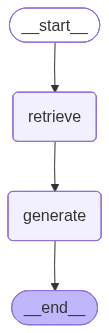

In [24]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [29]:
res = app.invoke({"question": "What is Deep mind goal?.", "docs": [], "answer": ""})
print(res["answer"])

DeepMind's goal is to apply the power of Deep Learning to the field of Reinforcement Learning, enabling systems to learn to perform tasks through trial and error without prior knowledge, ultimately achieving human-level performance in various applications, such as playing Atari games and the game of Go.


In [30]:
for doc in res['docs']:
  print(doc.page_content)
  print('*'*100)

Backgammon playing program) and in machine control, but seldom making the
headline news. But a revolution took place in 2013 when researchers from an English
startup called DeepMind demonstrated a system that could learn to play just about
any Atari game from scratch, 2 eventually outperforming humans 3 in most of them,
using only raw pixels as inputs and without any prior knowledge of the rules of the
games.4 This was the first of a series of amazing feats, culminating in March 2016
with the victory of their system AlphaGo against Lee Sedol, the world champion of
the game of Go. No program had ever come close to beating a master of this game, let
alone the world champion. Today the whole field of RL is boiling with new ideas, with
a wide range of applications. DeepMind was bought by Google for over 500 million
dollars in 2014.
****************************************************************************************************
a wide range of applications. DeepMind was bought by Google